## Finetuning

By Jenna Beauchain, Charlotte Burbridge, Andre Bergeron

Introduction:

Satellite images segmentation is important for identifying cropland and understanding agricultural patterns. Deep learning models like U-Nets are usually used for image segmentation tasks because of their ability to learn complex spatial features. Pretrained models can be adapted to new datasets using finetuning techniques. This project investiagtes how different finetuning strategies affect model performace on cropland segmentation. The finetuning stratgeies we used and compared are frozen-layer finetuning, progressive finetuning, and no finetuning.

Methods:

1. Dataset

The dataset used is this project is the *mapping-africa* dataset, which contains satelitte images of cropland across various regions in Africa. For this analysis, the dataset was filtered to include only samples from Zambia (ZM) in order to ensure consistency and allow for the model to run in a timely manner.

To filter out the Zambia data we used these commands in our terminal:

1. Step 1: create your working folders

mkdir -p /opt/app-root/src/transductivefeaturemaps/workdir/frozenlayerfinetune/v1 mkdir -p /opt/app-root/src/transductivefeaturemaps/workdir/frozenlayerfinetune/v1/logs mkdir -p /opt/app-root/src/transductivefeaturemaps/workdir/frozenlayerfinetune/v1/checkpoints


2. Step 2: Go into workdir

cd /opt/app-root/src/transductivefeaturemaps/workdir


3. Step 3: Copy to the original CSV

find /opt/app-root/src -name "croplands3-2.1.1_finetune_all_samples.csv" (take the path it outputs and run): cp <FOUND_PATH> /opt/app-root/src/transductivefeaturemaps/workdir/

4. Step 4: Create the ZM-only filtered CSV

python - <<'PY' import pandas as pd

infile = "/opt/app-root/src/transductivefeaturemaps/workdir/croplands3-2.1.1_finetune_all_samples.csv" outfile = "/opt/app-root/src/transductivefeaturemaps/workdir/frozenlayerfinetune/v1/croplands3-2.1.1_finetune_ZM_only.csv"

df = pd.read_csv(infile)

df_zm = df[df["cntry"].astype(str).str.lower() == "zm"].copy()

print("Original rows:", len(df)) print("ZM-only rows:", len(df_zm)) print(df_zm.head())

df_zm.to_csv(outfile, index=False) print("Saved:", outfile) PY

5. Step 5: Check if it worked

s /opt/app-root/src/transductivefeaturemaps/workdir/frozenlayerfinetune/v1 Should see something like: croplands3-2.1.1_finetune_ZM_only.csv logs checkpoints

This process filters the dataset to include only Zambia (ZM) samples and prepares it for input into the model.

2. Model

We used a pretrained segmentation model from the Fieldmapper Repo for this project. The model based on a U-Net architecture which is often used for image segmentation because uses encoder-decodeer structures and skip connections to combine low-level and high-level features. In this project, the model takes in satellties images of cropland and produces pixel-wise predictions.

3. Fine-tuning strategies

We chose three different finetuning strategies to evaluate how different levels of paramters updating can affect model perfromance on cropland segmentation. The three strategies we used are frozen-layer finetuning, progressive finetuning, and no finetuning or baseline.

1. Frozen-Layer Finetuning

Frozen-Layer finetuning is a technique where the earlier layers of a pretrained model are kept fixed while only the later and more task specific layers are updated during training.

2. Progressive Finetuning

Progressive finetuning is a technique where a model's layers are sequentially unfrozen.

3. No Finetuning

This method is the baseline which includes the basic methods for finetuning.

More details descriptions about each finetuning method can be found in accompanying finetuning documents.

5. Evaluation metrics

**Results/Analysis:** We used matplotlib to compare our 3 methods of finetuning




In [ ]:
# https://claude.ai/share/569b84f1-9796-4e07-8ff9-cda6720d644f
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BASE = Path('/opt/app-root/src/projects/transductivefeaturemaps/workdir')

# ── Model definitions ──────────────────────────────────────────────────────
# Each entry: (label, color, training_history_csv, metrics_csv, classwise_csv)
# Add more versions here if new checkpoints appear.
MODELS = [
    {
        'label':     'Progressive Finetune',
        'color':     'steelblue',
        'histories': [
            BASE / 'progressivefinetune/v3/checkpoint/unet_att_d_ep10/training_history.csv',
        ],
        'metrics':   BASE / 'progressivefinetune/v2/checkpoint/finetune_metrics.csv',
        'classwise': BASE / 'progressivefinetune/v2/checkpoint/finetune_metrics_classwise.csv',
    },
    {
        'label':     'Frozen Layer Finetune',
        'color':     'darkorange',
        'histories': [
            BASE / 'frozenlayerfinetune/v1/checkpoints/unet_att_d_ep10/training_history.csv',
        ],
        'metrics':   BASE / 'frozenlayerfinetune/v1/checkpoints/finetune_metrics.csv',
        'classwise': BASE / 'frozenlayerfinetune/v1/checkpoints/finetune_metrics_classwise.csv',
    },
    {
        'label':     'Unfreeze Finetune',
        'color':     'mediumseagreen',
        'histories': [
            BASE / 'unfreezefinetune/v2/checkpoint/unet_att_d_ep2/training_history.csv',
            BASE / 'unfreezefinetune/v2/checkpoint/unet_att_d_ep10/training_history.csv',
            BASE / 'unfreezefinetune/v2/checkpoint/unet_att_d_ep80/training_history.csv',
        ],
        'metrics':   BASE / 'unfreezefinetune/v2/checkpoint/finetune_metrics.csv',
        'classwise': BASE / 'unfreezefinetune/v2/checkpoint/finetune_metrics_classwise.csv',
    },
]

# ── Helpers ────────────────────────────────────────────────────────────────
def load_csv(path):
    """Load CSV; return None if missing or has no data rows."""
    p = Path(path)
    if not p.exists():
        return None
    try:
        df = pd.read_csv(p)
        return df if len(df) > 0 else None
    except Exception:
        return None

def best_history(paths):
    """Return the history CSV with the most rows (most complete run)."""
    best = None
    for p in paths:
        df = load_csv(p)
        if df is not None:
            if best is None or len(df) > len(best):
                best = df
    return best

# Pre-load everything
for m in MODELS:
    m['history_df']   = best_history(m['histories'])
    m['metrics_df']   = load_csv(m['metrics'])
    m['classwise_df'] = load_csv(m['classwise'])
    status = []
    if m['history_df']  is not None: status.append(f"history ({len(m['history_df'])} epochs)")
    if m['metrics_df']  is not None: status.append('metrics')
    if m['classwise_df']is not None: status.append('classwise')
    print(f"{m['label']}: {', '.join(status) if status else 'NO DATA YET'}")

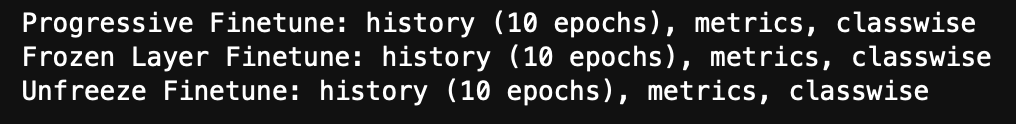

Train Loss Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
any_plotted = False

for m in MODELS:
    df = m['history_df']
    if df is None:
        print(f"  ⚠ {m['label']}: no training history yet")
        continue
    ax.plot(df['epoch'], df['train_loss'], 'o-', color=m['color'],
            label=m['label'], linewidth=2, markersize=5)
    any_plotted = True

if any_plotted:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss')
    ax.set_title('Train Loss — Model Comparison', fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparison_train_loss.png', bbox_inches='tight')
    plt.show()
    print('Saved → comparison_train_loss.png')
else:
    print('No training data available yet.')
    plt.close()

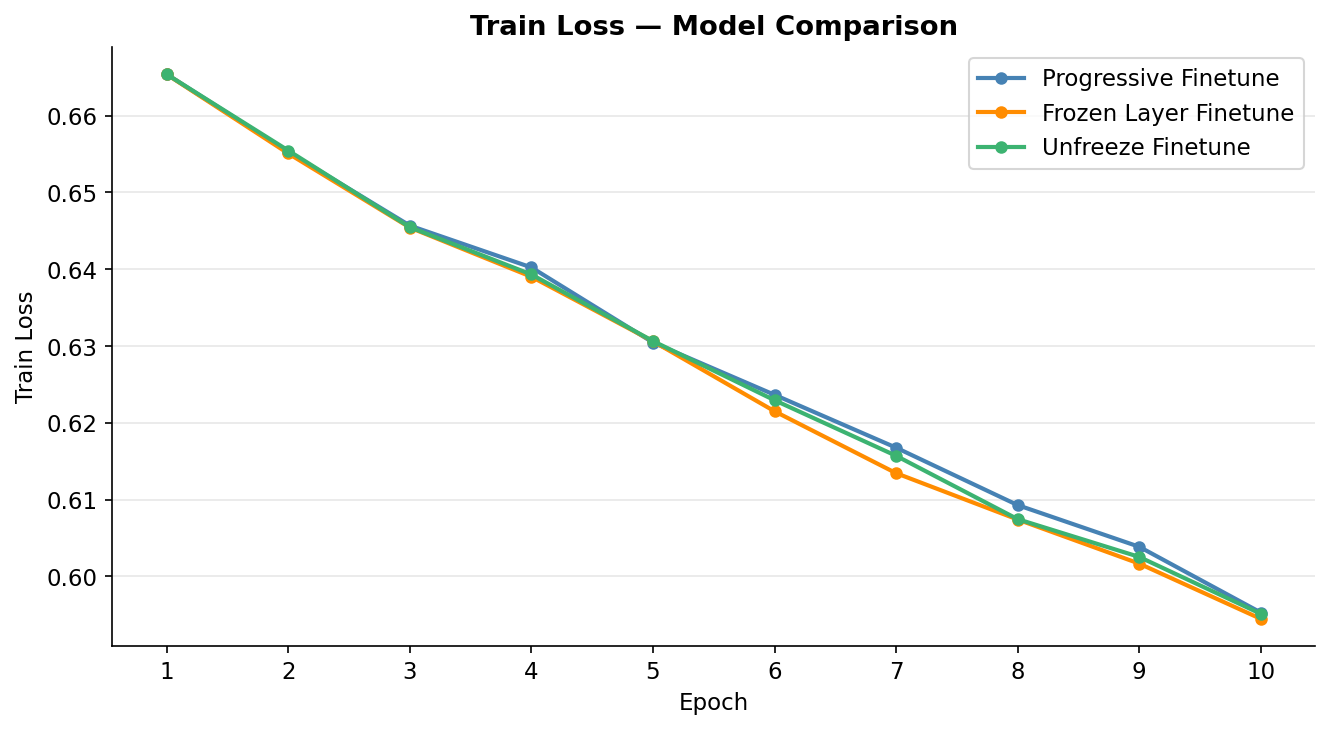

Validation Loss Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
any_plotted = False

for m in MODELS:
    df = m['history_df']
    if df is None:
        continue
    ax.plot(df['epoch'], df['val_loss'], 's-', color=m['color'],
            label=m['label'], linewidth=2, markersize=5)
    best_ep  = df.loc[df['val_loss'].idxmin(), 'epoch']
    best_val = df['val_loss'].min()
    ax.scatter(best_ep, best_val, s=100, color=m['color'], zorder=5,
               edgecolors='black', linewidth=1)
    any_plotted = True

if any_plotted:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Loss')
    ax.set_title('Validation Loss — Model Comparison\n(★ = best val epoch per model)', fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparison_val_loss.png', bbox_inches='tight')
    plt.show()
    print('Saved → comparison_val_loss.png')
else:
    print('No validation data available yet.')
    plt.close()

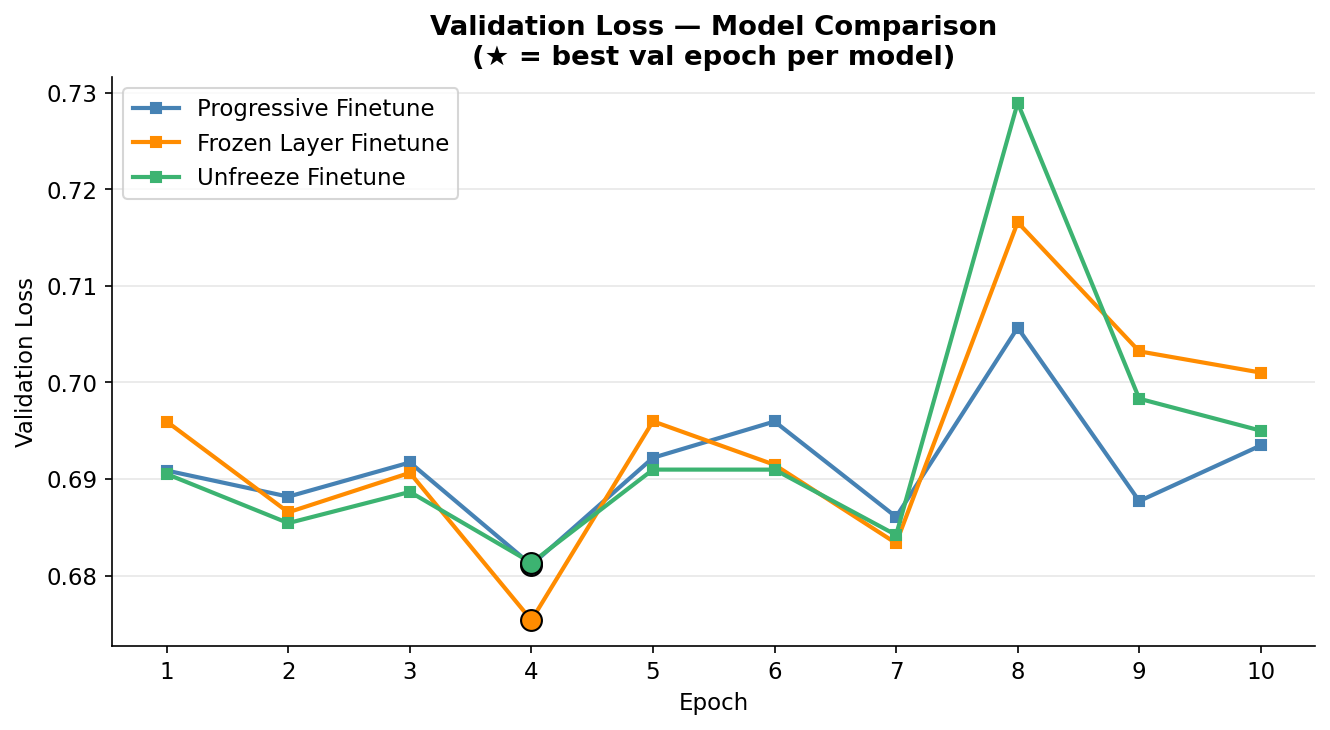

Validation Metrics per Epoch

In [ ]:
metric_cols = [
    ('overall_accuracy', 'Overall Accuracy'),
    ('mean_iou',         'Mean IoU'),
    ('mean_f1_score',    'Mean F1 Score'),
    ('mean_accuracy',    'Mean Accuracy'),
    ('mean_precision',   'Mean Precision'),
    ('mean_recall',      'Mean Recall'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)
axes = axes.flatten()

for ax, (col, title) in zip(axes, metric_cols):
    any_plotted = False
    for m in MODELS:
        df = m['history_df']
        if df is None or col not in df.columns:
            continue
        ax.plot(df['epoch'], df[col], 'o-', color=m['color'],
                label=m['label'], linewidth=2, markersize=4)
        any_plotted = True
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3)
    if any_plotted:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No data yet', transform=ax.transAxes,
                ha='center', va='center', color='grey', fontsize=10)

fig.suptitle('Validation Metrics per Epoch — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_val_metrics_per_epoch.png', bbox_inches='tight')
plt.show()
print('Saved → comparison_val_metrics_per_epoch.png')

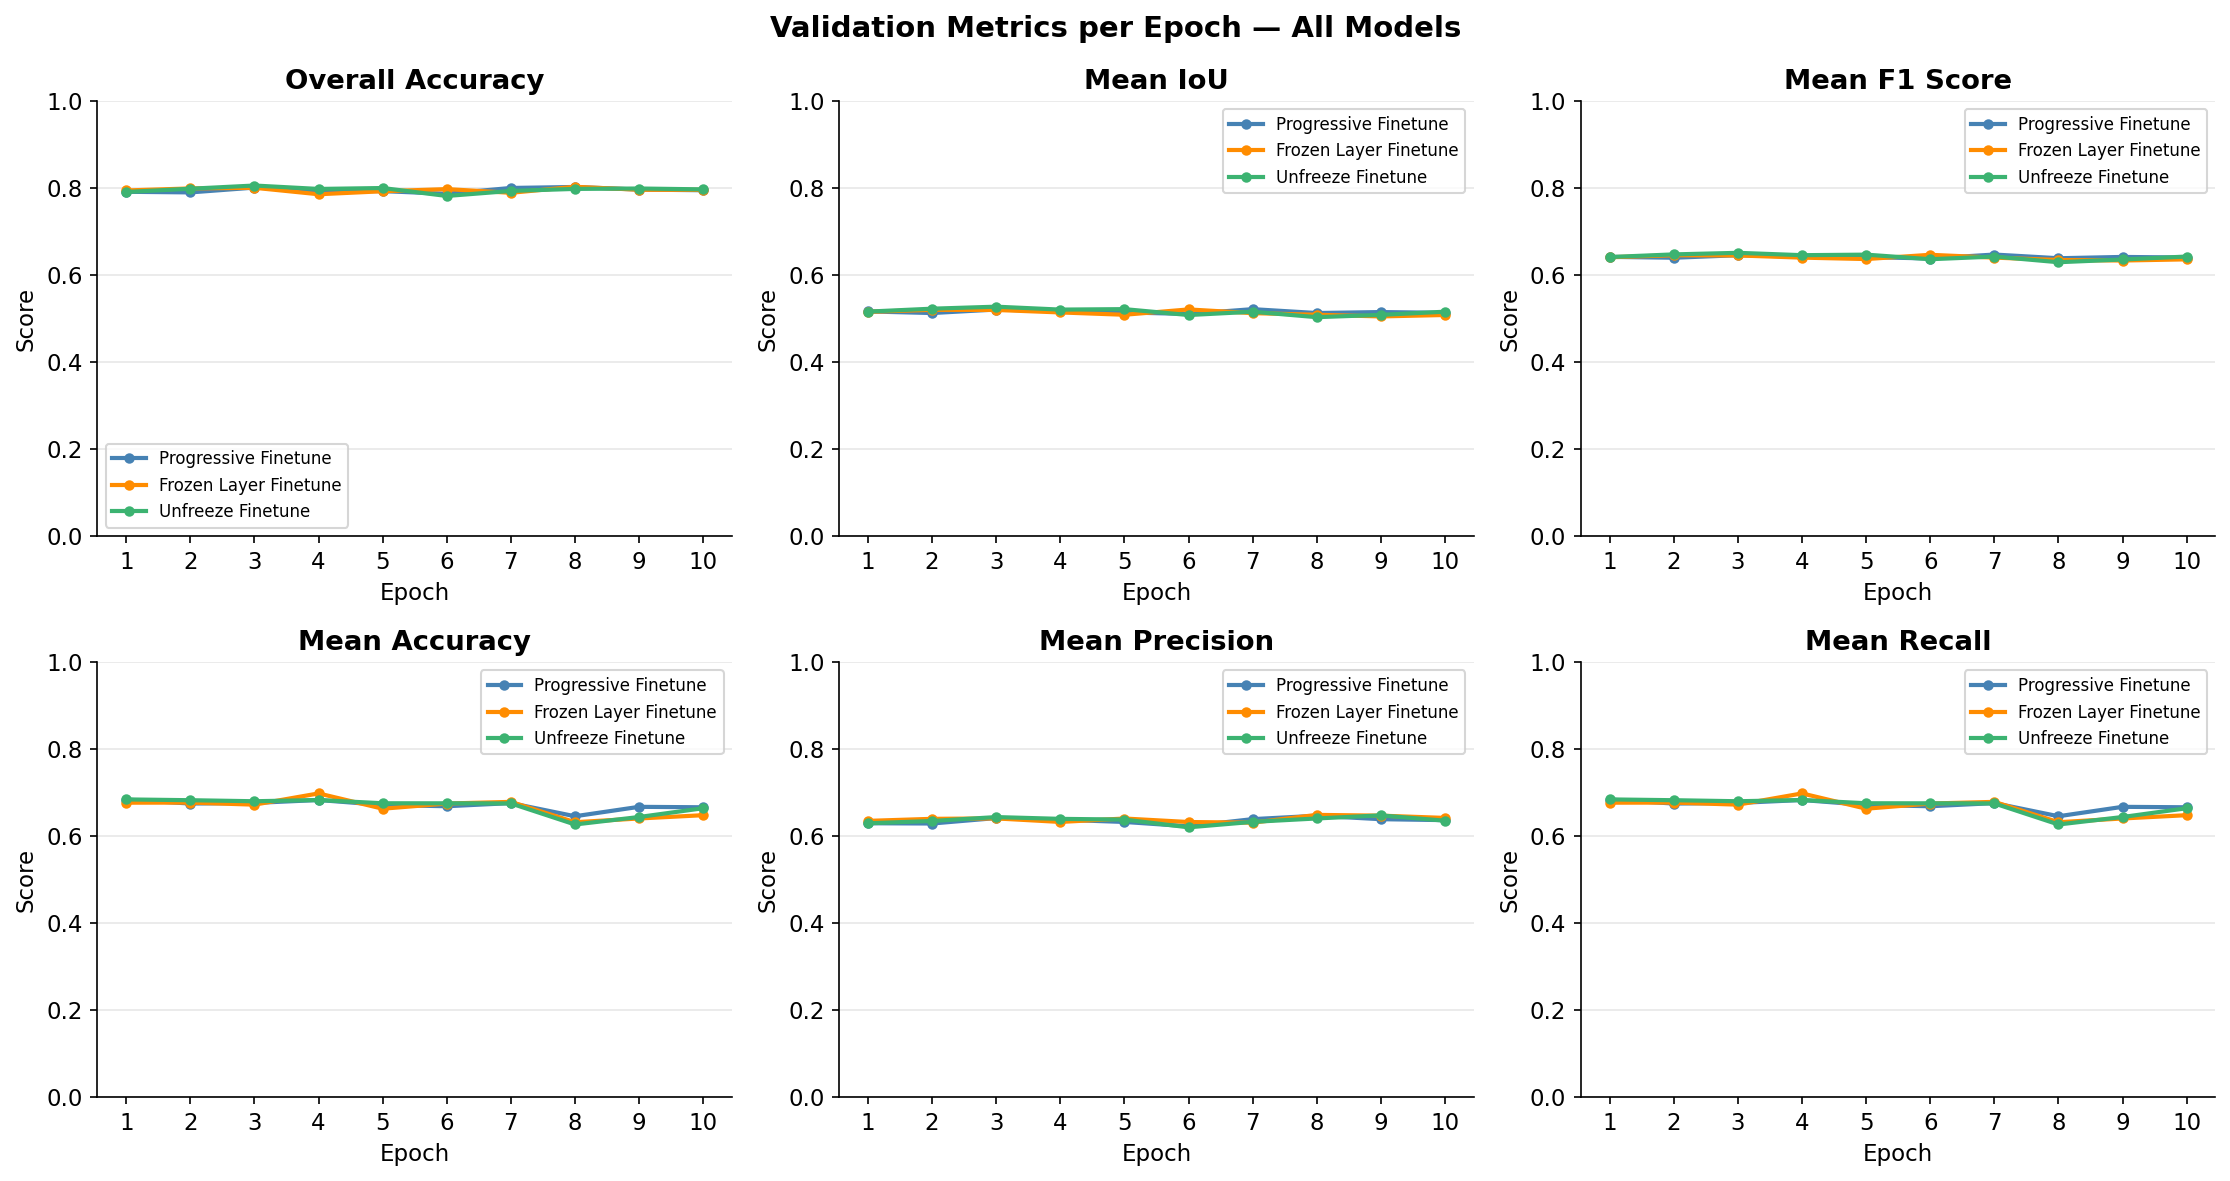

Learning Rate Schedules

In [ ]:
available = [m for m in MODELS if m['history_df'] is not None]
if not available:
    print('No LR data yet.')
else:
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 3.5), sharey=False)
    if len(available) == 1:
        axes = [axes]
    for ax, m in zip(axes, available):
        df = m['history_df']
        ax.step(df['epoch'], df['lr'], where='post', color=m['color'], linewidth=2)
        ax.fill_between(df['epoch'], df['lr'], step='post', alpha=0.15, color=m['color'])
        ax.set_title(m['label'], fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
        ax.grid(axis='y', alpha=0.3)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    fig.suptitle('Learning Rate Schedules', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('comparison_lr_schedules.png', bbox_inches='tight')
    plt.show()
    print('Saved → comparison_lr_schedules.png')

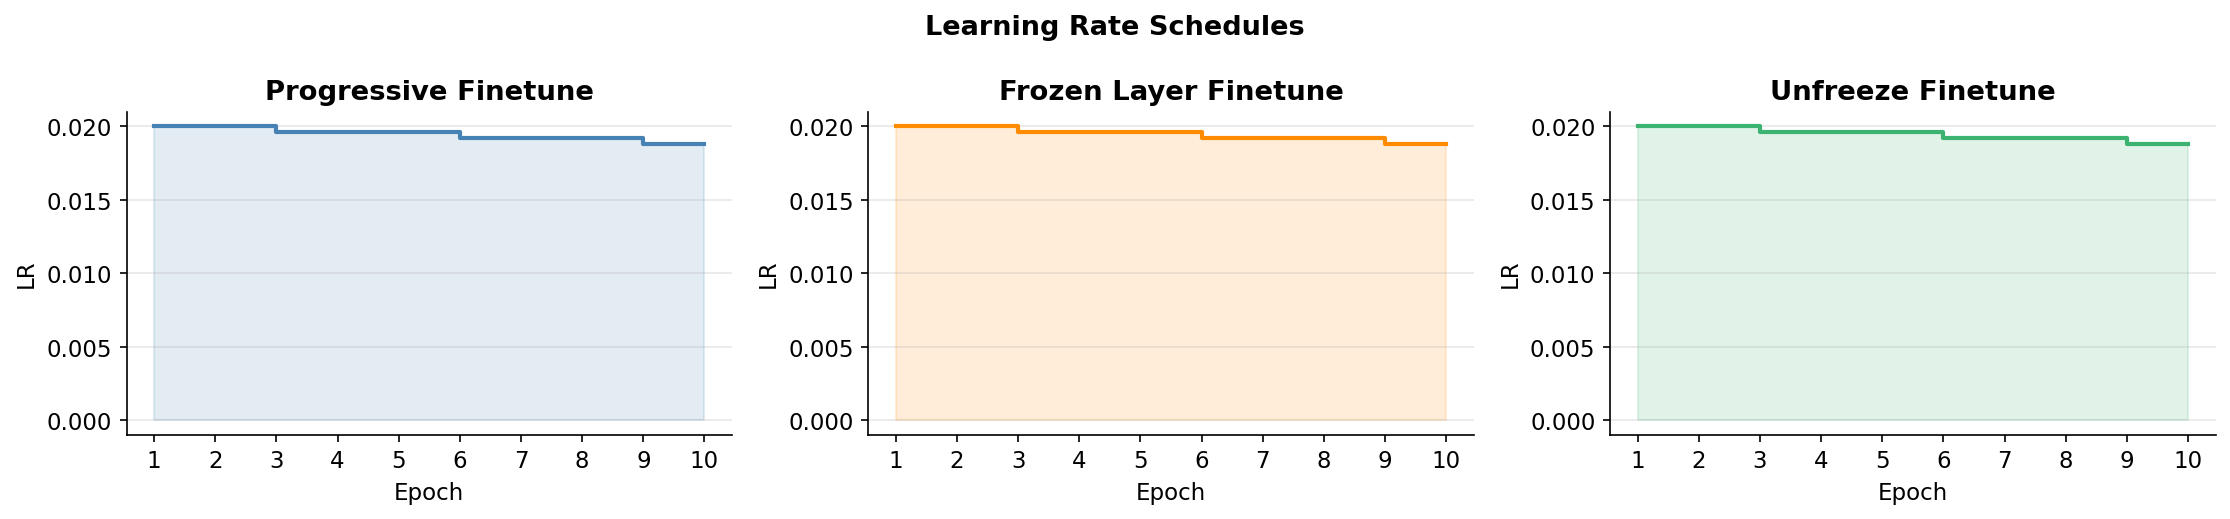

Final Evaluation Metrics

In [ ]:
eval_metrics = ['Overall Accuracy', 'Mean Accuracy', 'Mean IoU', 'Mean Precision', 'mean Recall', 'Mean F1 Score']
# Normalise column name differences
rename_map = {'mean Precision': 'Mean Precision', 'mean Recall': 'Mean Recall'}

available = [m for m in MODELS if m['metrics_df'] is not None]
if not available:
    print('No final evaluation metrics available yet — run complete at least one model.')
else:
    x     = np.arange(len(eval_metrics))
    width = 0.8 / len(available)

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, m in enumerate(available):
        df = m['metrics_df'].copy()
        df['Metric'] = df['Metric'].replace(rename_map)
        vals = []
        for em in eval_metrics:
            row = df[df['Metric'].str.strip() == em]
            vals.append(row['Value'].values[0] if len(row) > 0 else 0)
        offset = (i - (len(available) - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width * 0.9, label=m['label'],
                      color=m['color'], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels(['Overall\nAccuracy','Mean\nAccuracy','Mean\nIoU',
                         'Mean\nPrecision','Mean\nRecall','Mean\nF1'], fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title('Final Evaluation Metrics — Model Comparison', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparison_final_metrics.png', bbox_inches='tight')
    plt.show()
    print('Saved → comparison_final_metrics.png')

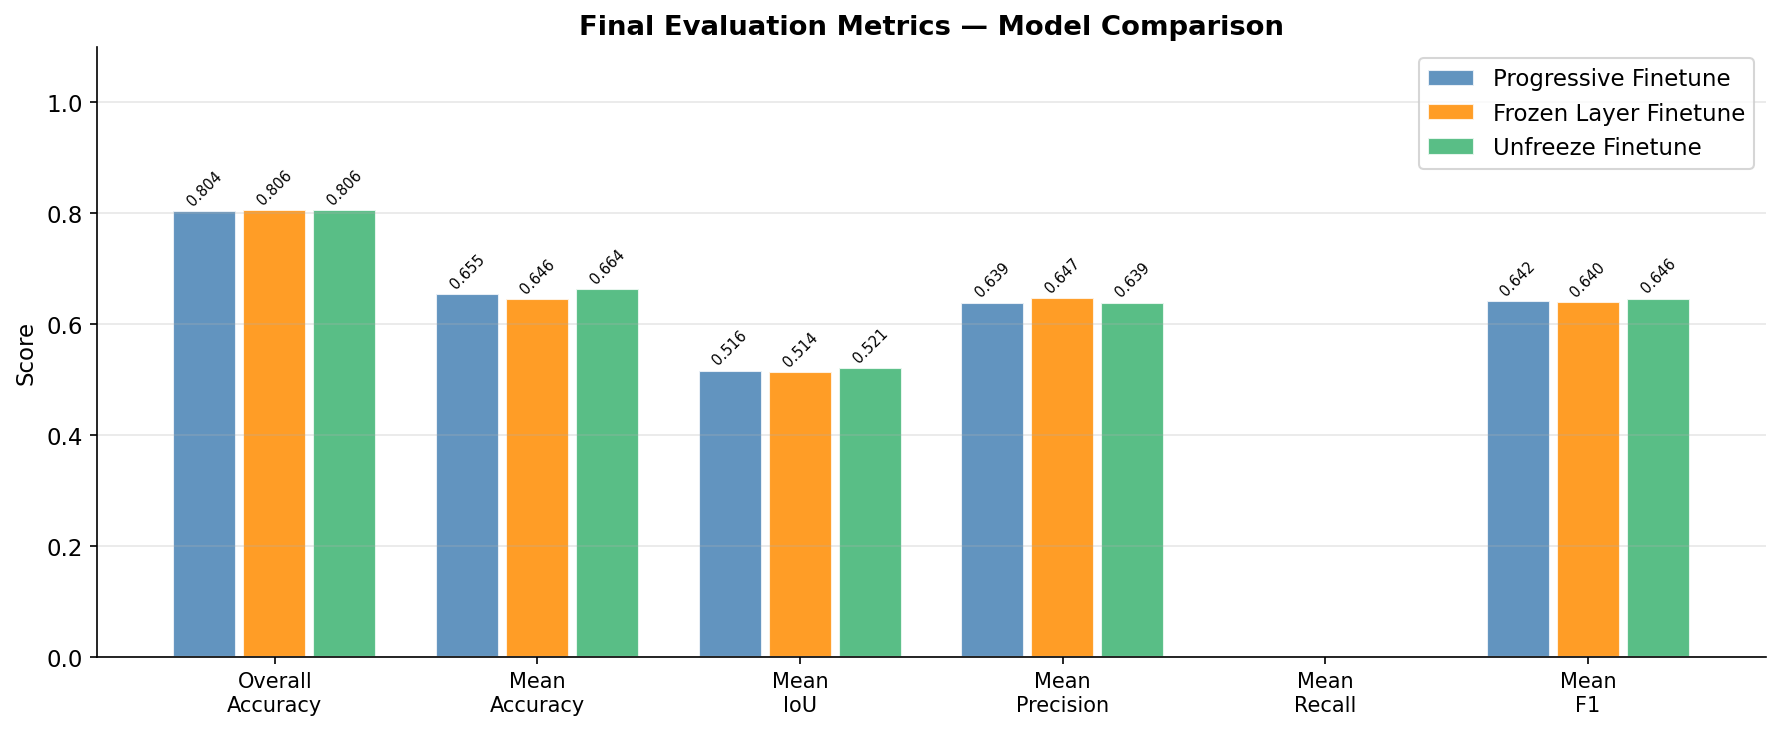

Class-wise Metrics per Model

In [ ]:
cw_cols   = ['Accuracy', 'IoU', 'Precision', 'Recall', 'F1 Score']
cw_colors = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato', 'mediumorchid']

available = [m for m in MODELS if m['classwise_df'] is not None]
if not available:
    print('No class-wise metrics available yet.')
else:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5), sharey=True)
    if len(available) == 1:
        axes = [axes]

    for ax, m in zip(axes, available):
        df      = m['classwise_df']
        classes = df['Class'].tolist()
        xpos    = np.arange(len(classes))
        w       = 0.15
        for i, (col, clr) in enumerate(zip(cw_cols, cw_colors)):
            offset = (i - 2) * w
            ax.bar(xpos + offset, df[col], w, label=col, color=clr, alpha=0.85, edgecolor='white')
        ax.set_xticks(xpos)
        ax.set_xticklabels(classes, fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_title(m['label'], fontweight='bold')
        ax.set_ylabel('Score')
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    fig.suptitle('Class-wise Evaluation Metrics — All Models', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('comparison_classwise.png', bbox_inches='tight')
    plt.show()
    print('Saved → comparison_classwise.png')

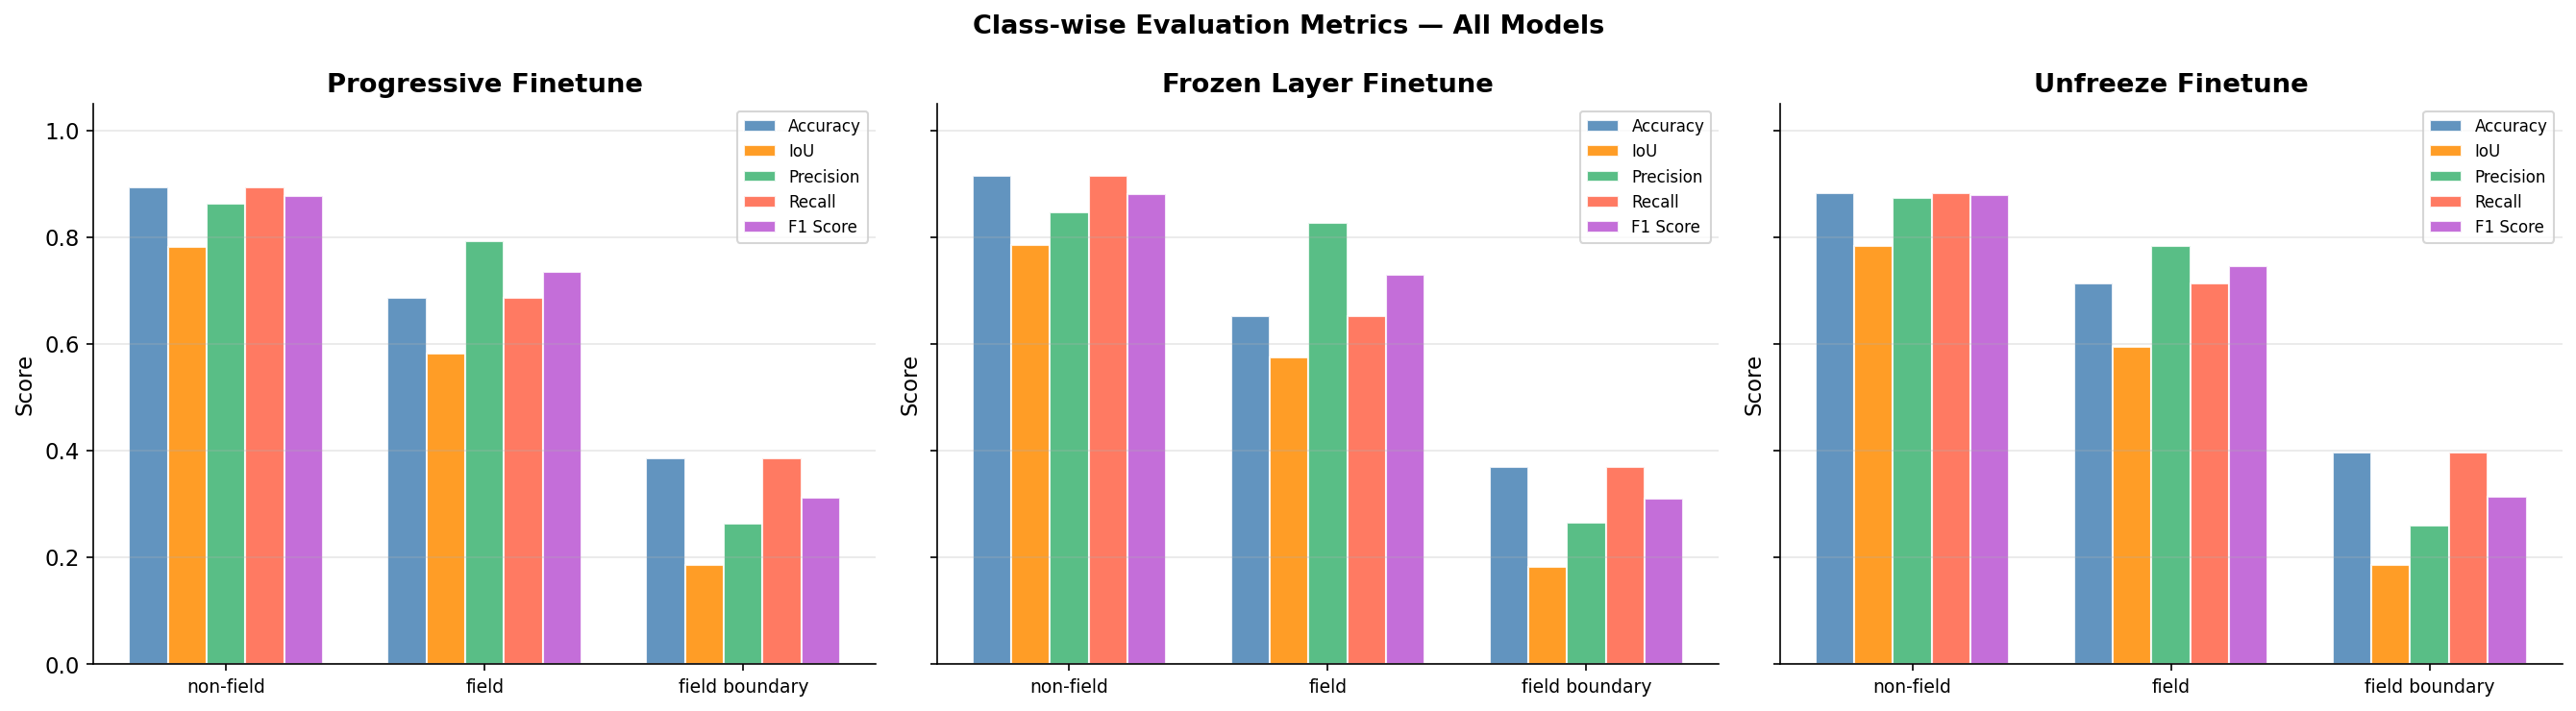

Class-wise IoU Comparsion across Models

In [ ]:
available = [m for m in MODELS if m['classwise_df'] is not None]
if not available:
    print('No class-wise data yet.')
else:
    # Use the class list from first available model
    classes = available[0]['classwise_df']['Class'].tolist()
    x       = np.arange(len(classes))
    width   = 0.8 / len(available)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, m in enumerate(available):
        df     = m['classwise_df']
        offset = (i - (len(available) - 1) / 2) * width
        bars   = ax.bar(x + offset, df['IoU'], width * 0.9,
                        label=m['label'], color=m['color'], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, df['IoU']):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('IoU')
    ax.set_title('Class-wise IoU — Model Comparison', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparison_classwise_iou.png', bbox_inches='tight')
    plt.show()
    print('Saved → comparison_classwise_iou.png')

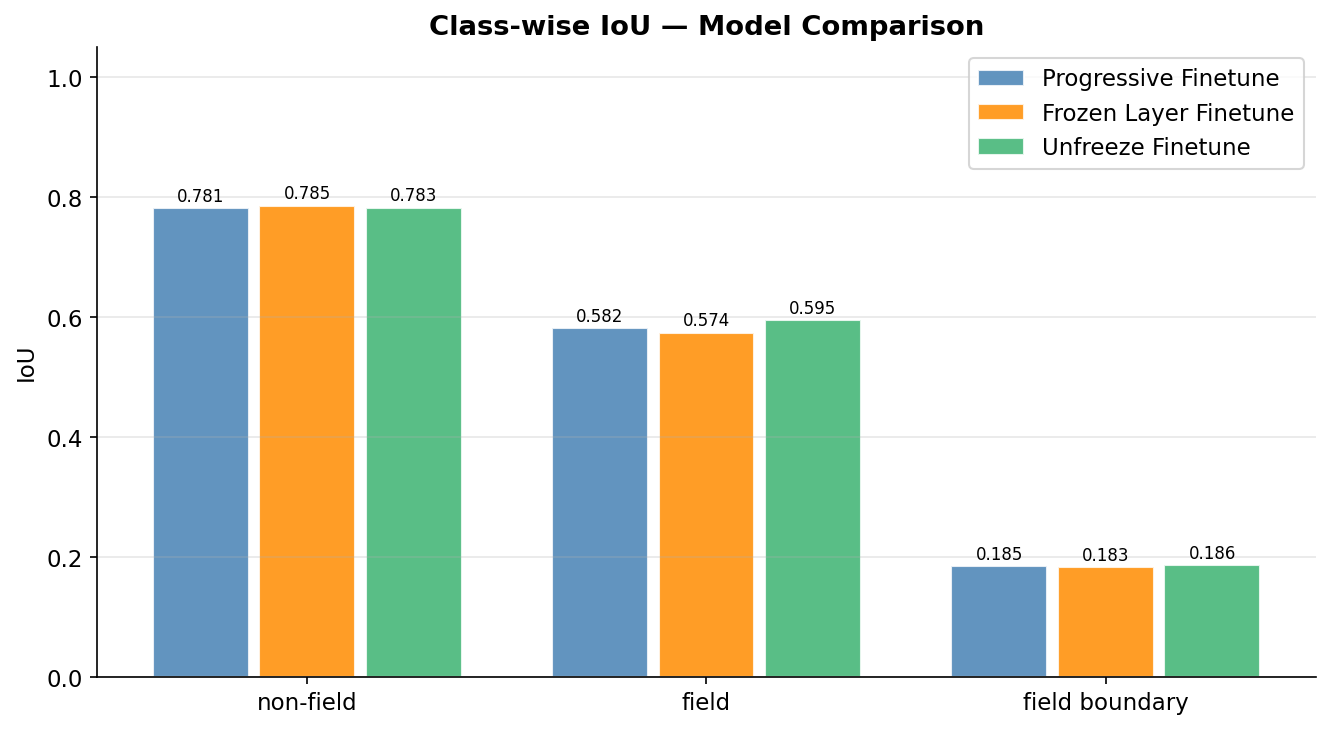

Summar Table

In [ ]:
rename_map = {'mean Precision': 'Mean Precision', 'mean Recall': 'Mean Recall'}
rows = []
for m in MODELS:
    row = {'Model': m['label']}
    if m['history_df'] is not None:
        df = m['history_df']
        row['Epochs run']      = len(df)
        row['Best val loss']   = round(df['val_loss'].min(), 4)
        row['Best val epoch']  = int(df.loc[df['val_loss'].idxmin(), 'epoch'])
        row['Final train loss']= round(df['train_loss'].iloc[-1], 4)
    if m['metrics_df'] is not None:
        mdf = m['metrics_df'].copy()
        mdf['Metric'] = mdf['Metric'].replace(rename_map)
        for met in ['Overall Accuracy', 'Mean IoU', 'Mean F1 Score']:
            r = mdf[mdf['Metric'].str.strip() == met]
            if len(r):
                row[met] = round(r['Value'].values[0], 4)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())
summary

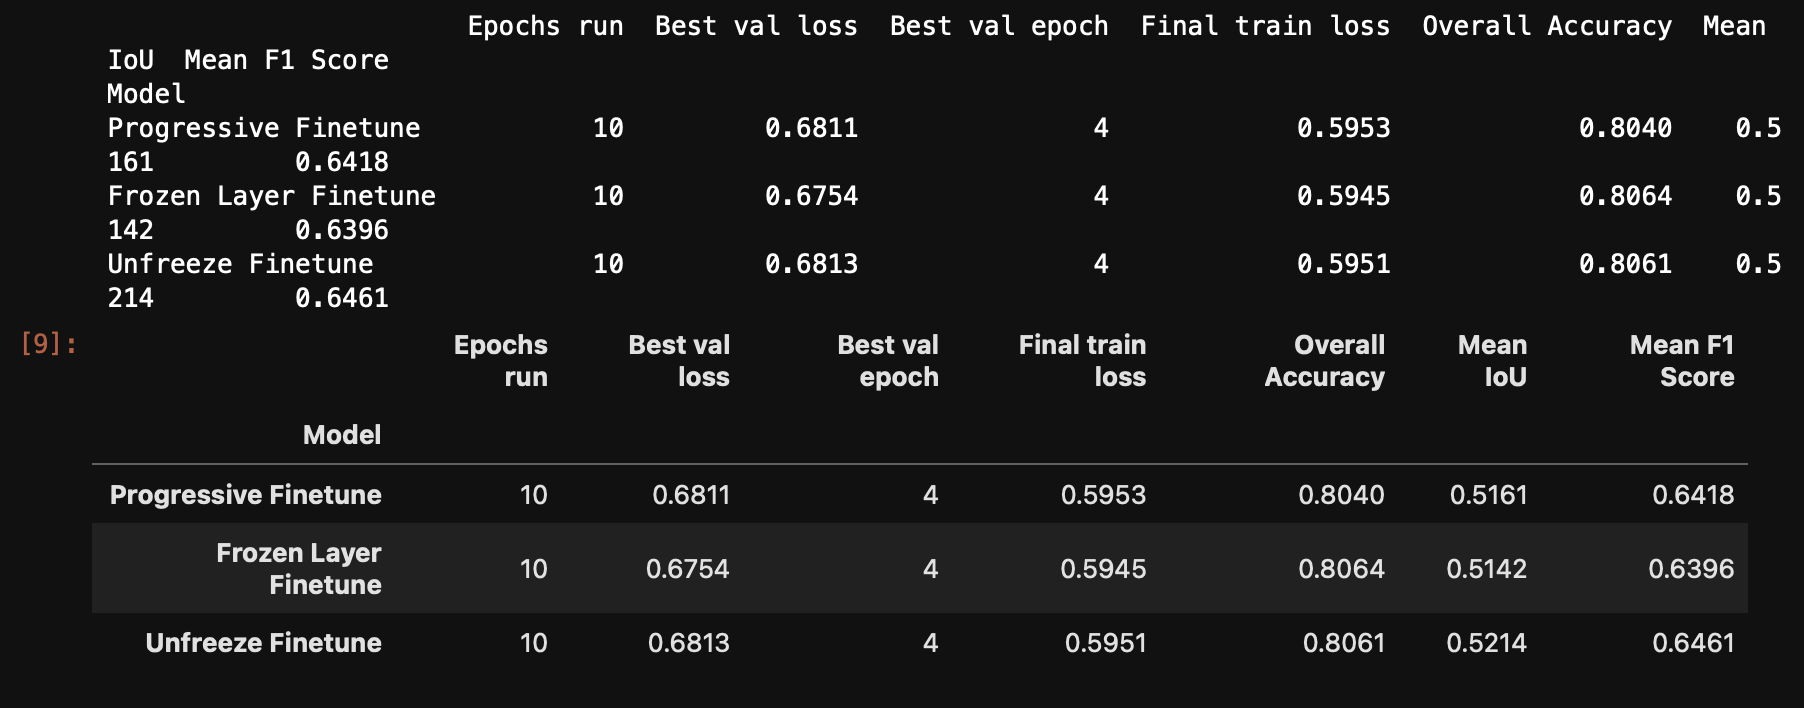

**Discussion:**

All of the finetuning methods (frozen-layer, progressive, and no finetuning), ended with about the same final training loss and accuracy. This suggests that the current project set up does not allow for a clear distinction between the methods.

With a larger dataset, more epochs, and some generalization techniques, there might've been a larger difference. But with the 10 epochs they all looked very similar in their performance.